## Script to open praat files and visualize the output

#### Opens the TextGrid file and extracts the information related to the marked times done in the Praat software

In [3]:
def parse_textgrid(file_path):
    """
    Parse a Praat TextGrid file manually and extract tiers, intervals, and labels.
    """
    tiers = []  # List to store tier information
    current_tier = None

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            lines = file.readlines()
            for line in lines:
                line = line.strip()

                # Detect a new tier
                if line.startswith("name ="):
                    tier_name = line.split("=")[1].strip().strip('"')
                    current_tier = {
                        "name": tier_name,
                        "intervals": []
                    }
                    tiers.append(current_tier)

                # Extract interval start
                elif line.startswith("xmin ="):
                    start_time = float(line.split("=")[1].strip())
                
                # Extract interval end
                elif line.startswith("xmax ="):
                    end_time = float(line.split("=")[1].strip())
                
                # Extract interval label
                elif line.startswith("text ="):
                    label = line.split("=")[1].strip().strip('"')
                    if current_tier is not None:
                        current_tier["intervals"].append({
                            "start": start_time,
                            "end": end_time,
                            "label": label
                        })

        return tiers

    except Exception as e:
        print(f"Error reading TextGrid: {e}")
        return None


# Example Usage
if __name__ == "__main__":
    # Path to the .TextGrid file
    textgrid_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML.TextGrid"
    print("Reading TextGrid:")

    tiers = parse_textgrid(textgrid_path)
    if tiers:
        for tier in tiers:
            print(f"\nTier Name: {tier['name']}")
            for interval in tier['intervals']:
                print(f"  Start: {interval['start']}, End: {interval['end']}, Label: {interval['label']}")


Reading TextGrid:

Tier Name: GE_F1_3ML
  Start: 0.0, End: 0.005914280588263696, Label: 
  Start: 0.005914280588263696, End: 0.390019545403464, Label: som1
  Start: 0.390019545403464, End: 0.39279286861512613, Label: 
  Start: 0.39279286861512613, End: 0.6021787710956144, Label: som2
  Start: 0.6021787710956144, End: 0.6049520943072765, Label: 
  Start: 0.6049520943072765, End: 1.44425, Label: som3


#### After analysing the output of the previous code, the unrelated time marks are stripped 

In [4]:
def parse_textgrid(file_path, filter_labels=None):
    """
    Parse a Praat TextGrid file manually and extract tiers, intervals, and labels.
    Filters intervals based on specified labels.
    """
    tiers = []  # List to store tier information
    current_tier = None
    results = []  # Store filtered intervals

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            lines = file.readlines()
            for line in lines:
                line = line.strip()

                # Detect a new tier
                if line.startswith("name ="):
                    tier_name = line.split("=")[1].strip().strip('"')
                    current_tier = {
                        "name": tier_name,
                        "intervals": []
                    }
                    tiers.append(current_tier)

                # Extract interval start
                elif line.startswith("xmin ="):
                    start_time = float(line.split("=")[1].strip())
                
                # Extract interval end
                elif line.startswith("xmax ="):
                    end_time = float(line.split("=")[1].strip())
                
                # Extract interval label
                elif line.startswith("text ="):
                    label = line.split("=")[1].strip().strip('"')
                    if current_tier is not None:
                        interval = {
                            "start": start_time,
                            "end": end_time,
                            "label": label
                        }
                        current_tier["intervals"].append(interval)

                        # Add to results if label matches filter
                        if filter_labels is None or label in filter_labels:
                            results.append({
                                "tier": tier_name,
                                "start": start_time,
                                "end": end_time,
                                "label": label
                            })

        return results

    except Exception as e:
        print(f"Error reading TextGrid: {e}")
        return None


# Example Usage
if __name__ == "__main__":
    textgrid_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML.TextGrid"
    filter_labels = {"som1", "som2", "som3"}  # Labels to extract

    print("Extracting intervals with specified labels:")
    intervals = parse_textgrid(textgrid_path, filter_labels)

    if intervals:
        for interval in intervals:
            print(f"Tier: {interval['tier']}, Start: {interval['start']}, End: {interval['end']}, Label: {interval['label']}")

Extracting intervals with specified labels:
Tier: GE_F1_3ML, Start: 0.005914280588263696, End: 0.390019545403464, Label: som1
Tier: GE_F1_3ML, Start: 0.39279286861512613, End: 0.6021787710956144, Label: som2
Tier: GE_F1_3ML, Start: 0.6049520943072765, End: 1.44425, Label: som3


#### Combination of wav. file and the output information extracted from the TextGrid file

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

def plot_waveform_with_intervals(wav_file_path, intervals):
    """
    Plot the waveform of an audio file and overlay intervals from the TextGrid file.

    Parameters:
    - wav_file_path: Path to the .wav file
    - intervals: List of dictionaries with 'start', 'end', and 'label'
    """
    # Load the audio file
    audio, sr = librosa.load(wav_file_path, sr=None)
    duration = librosa.get_duration(y=audio, sr=sr)

    # Create the time axis for the waveform
    time = np.linspace(0, duration, len(audio))

    # Plot the waveform
    plt.figure(figsize=(12, 6))
    librosa.display.waveshow(audio, sr=sr, alpha=0.7, label="Waveform")
    plt.title("Waveform with Intervals")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Overlay intervals
    for interval in intervals:
        start = interval["start"]
        end = interval["end"]
        label = interval["label"]
        plt.axvspan(start, end, color='orange', alpha=0.3, label=f"{label}")  # Shaded region for the interval
        plt.text((start + end) / 2, max(audio), label, ha='center', va='bottom', fontsize=10, color='red')

    # Remove duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    # Show the plot
    plt.tight_layout()
    plt.show()


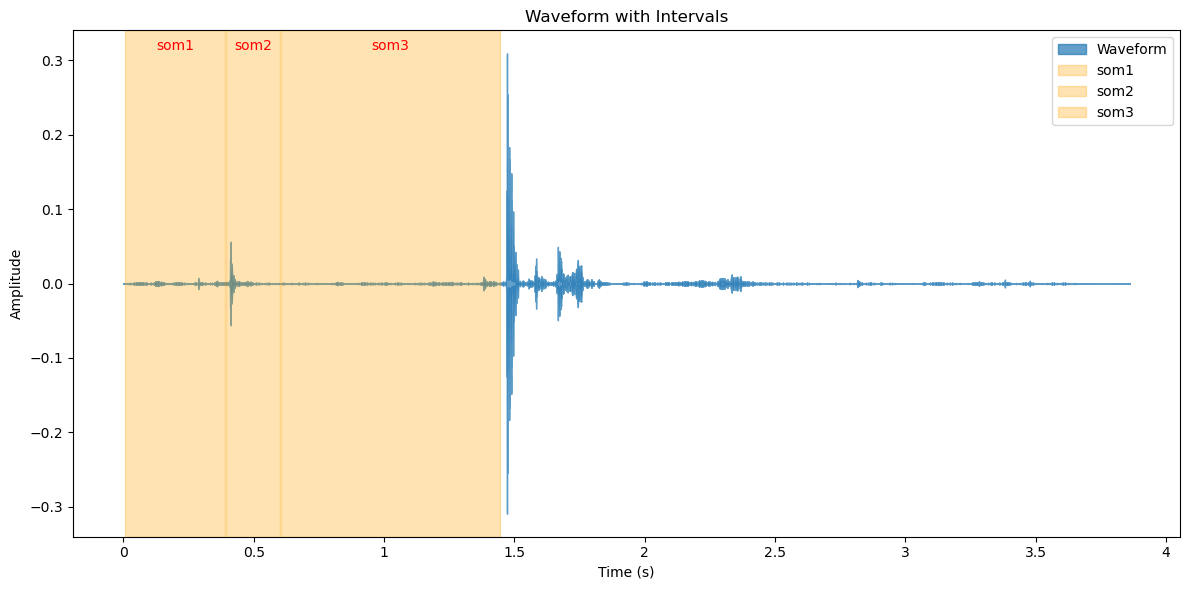

In [3]:
wav_file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML - S.wav"
intervals = [
    {"start": 0.005914280588263696, "end": 0.390019545403464, "label": "som1"},
    {"start": 0.39279286861512613, "end": 0.6021787710956144, "label": "som2"},
    {"start": 0.6049520943072765, "end": 1.44425, "label": "som3"}
]
plot_waveform_with_intervals(wav_file_path, intervals)